# Libraries & Engine

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root) )

d:\ML Projects\Olist_Elfarghaly\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.warehouse.engine import get_db_engine

engine = get_db_engine()

Database connection successful!


# EDA

In [3]:
Dim_Customers = pd.read_sql("SELECT * FROM Gold.Dim_Customers", engine)
Dim_Date = pd.read_sql("SELECT * FROM Gold.Dim_Date", engine)
Dim_Products = pd.read_sql("SELECT * FROM Gold.Dim_Products", engine)
Dim_Sellers = pd.read_sql("SELECT * FROM Gold.Dim_Sellers", engine)
Fact_Orders = pd.read_sql("SELECT * FROM Gold.Fact_Orders", engine)
Fact_Orders_Items = pd.read_sql("SELECT * FROM Gold.Fact_Order_Items", engine)
Fact_Marketing = pd.read_sql("SELECT * FROM Gold.Fact_Marketing_Funnel", engine)

print("Dim_Customers shape:", Dim_Customers.shape)
print("Dim_Date shape:", Dim_Date.shape)
print("Dim_Products shape:", Dim_Products.shape)
print("Dim_Sellers shape:", Dim_Sellers.shape)
print("Fact_Orders shape:", Fact_Orders.shape)
print("Fact_Orders_Items shape:", Fact_Orders_Items.shape)
print("Fact_Marketing shape:", Fact_Marketing.shape)

Dim_Customers shape: (96096, 7)
Dim_Date shape: (2192, 9)
Dim_Products shape: (32951, 12)
Dim_Sellers shape: (3095, 14)
Fact_Orders shape: (99441, 12)
Fact_Orders_Items shape: (112650, 11)
Fact_Marketing shape: (8000, 11)


## Dim_Customers

--- Missing Values ---
customer_unique_id       0
zip_code                 0
city                     0
state                    0
latitude               268
longitude              268
load_date_timestamp      0
dtype: int64

Total Duplicate Customer IDs: 0


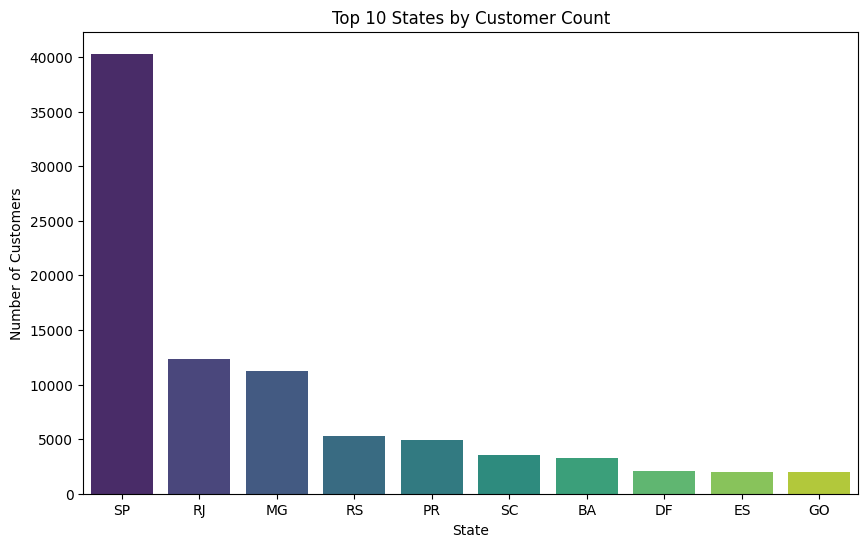

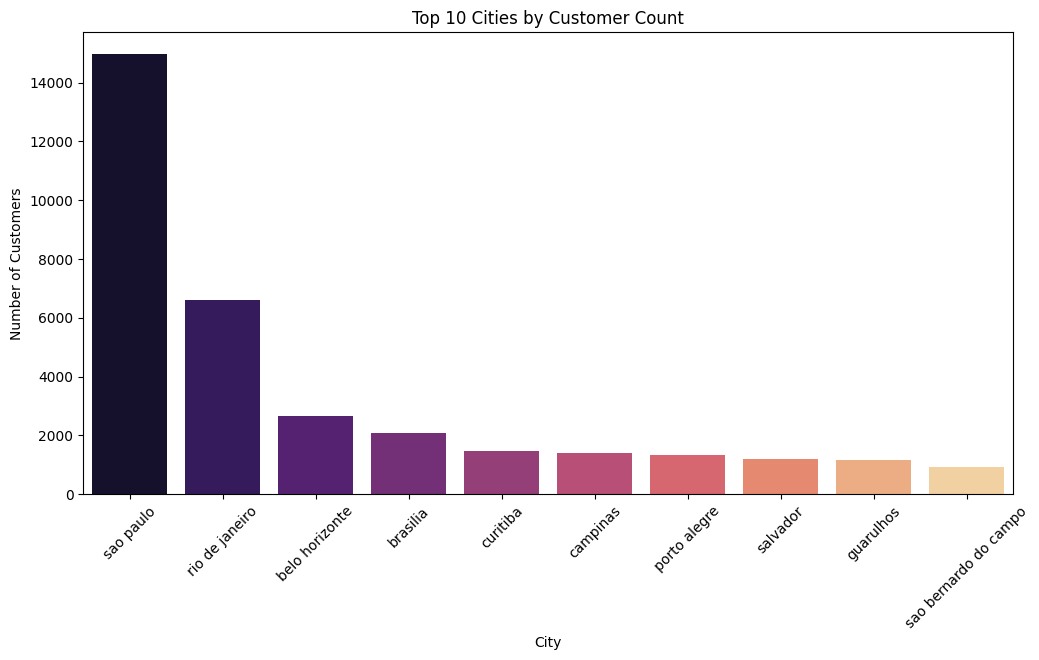

In [4]:
print("--- Missing Values ---")
print(Dim_Customers.isnull().sum())
print(f"\nTotal Duplicate Customer IDs: {Dim_Customers['customer_unique_id'].duplicated().sum()}")

top_states = Dim_Customers['state'].value_counts().head(10).reset_index()
top_states.columns = ['state', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_states, x='state', y='count', palette='viridis')
plt.title('Top 10 States by Customer Count')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

top_cities = Dim_Customers['city'].value_counts().head(10).reset_index()
top_cities.columns = ['city', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cities, x='city', y='count', palette='magma')
plt.title('Top 10 Cities by Customer Count')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

## Dim_Products

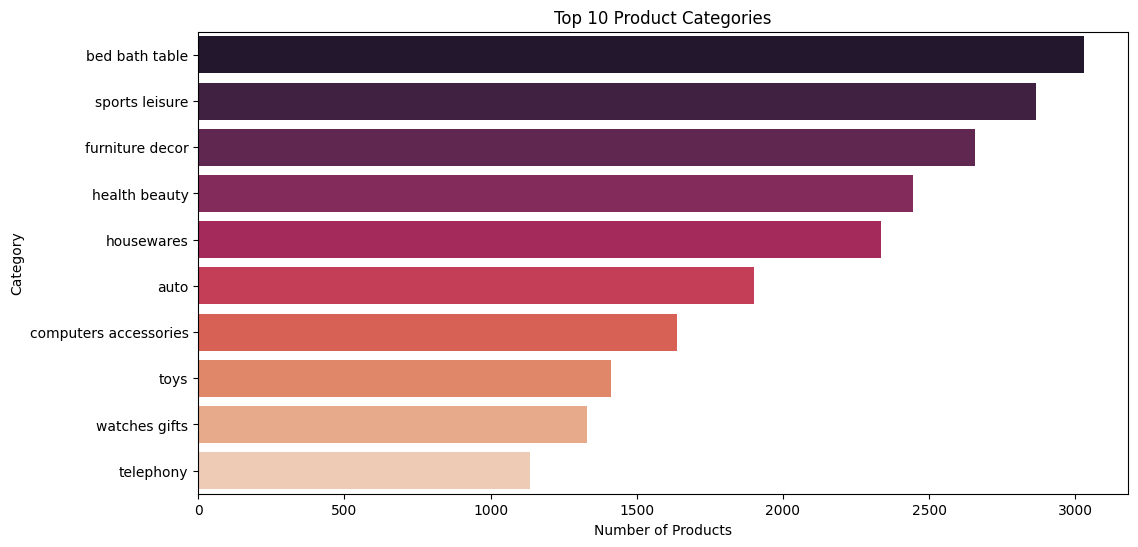

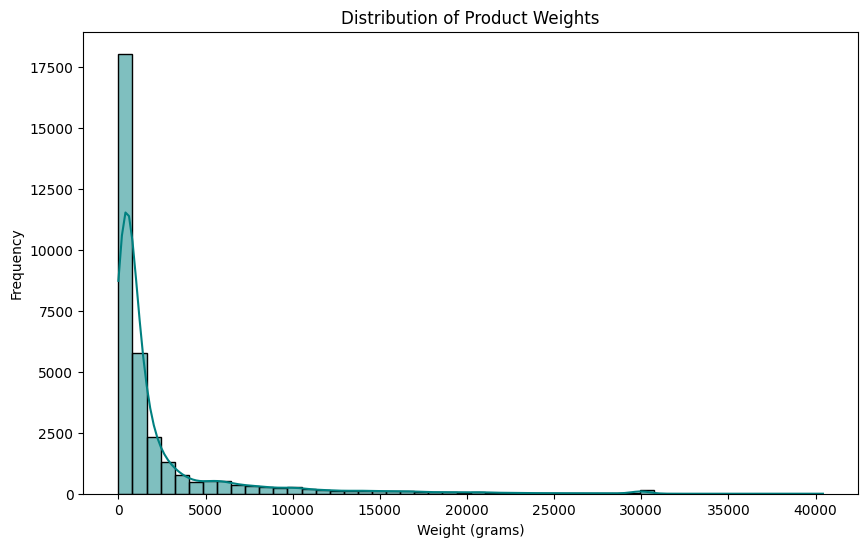

Missing Values Summary:
product_id               0
category_name_pt       610
category_name_en       623
name_length            610
description_length     610
photo_count            610
weight_g                 2
length_cm                2
height_cm                2
width_cm                 2
volume_cm3               2
load_date_timestamp      0
dtype: int64


In [5]:
top_categories = Dim_Products['category_name_en'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='rocket')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(Dim_Products['weight_g'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Product Weights')
plt.xlabel('Weight (grams)')
plt.ylabel('Frequency')
plt.show()

print("Missing Values Summary:")
print(Dim_Products.isnull().sum())

## Dim_Sellers

--- Missing Values Percentage ---
seller_id                     0.0%
zip_code                      0.0%
city                         0.06%
state                         0.0%
latitude                     1.36%
longitude                    1.36%
business_segment            87.72%
business_type               87.82%
lead_type                   87.82%
behaviour_profile           90.66%
catalog_size                100.0%
declared_monthly_revenue    87.72%
came_from_marketing           0.0%
load_date_timestamp           0.0%
dtype: object


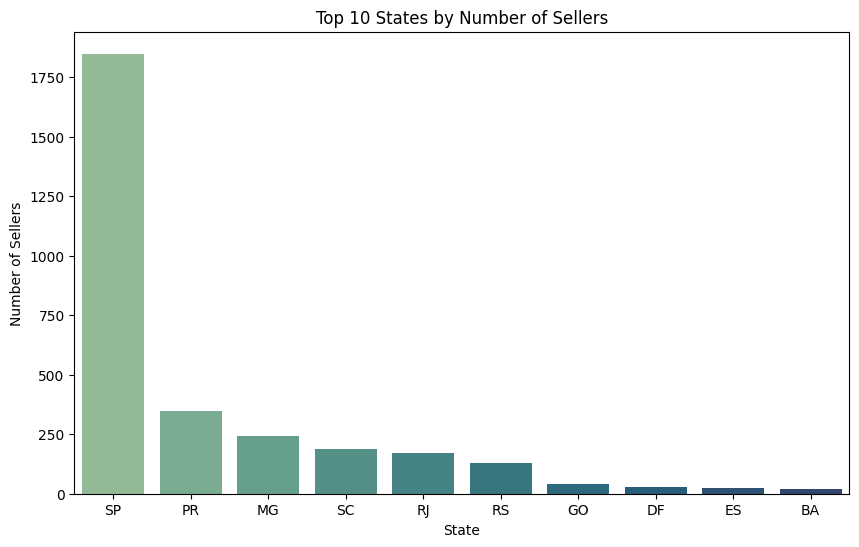

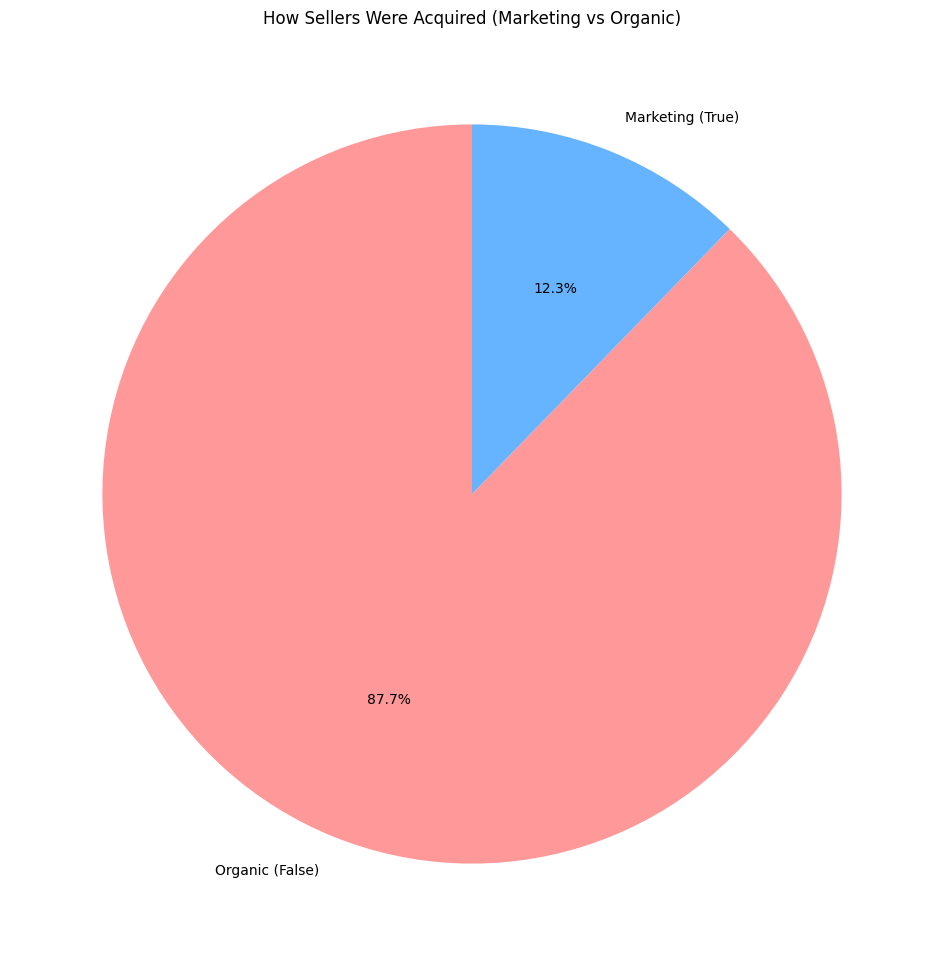

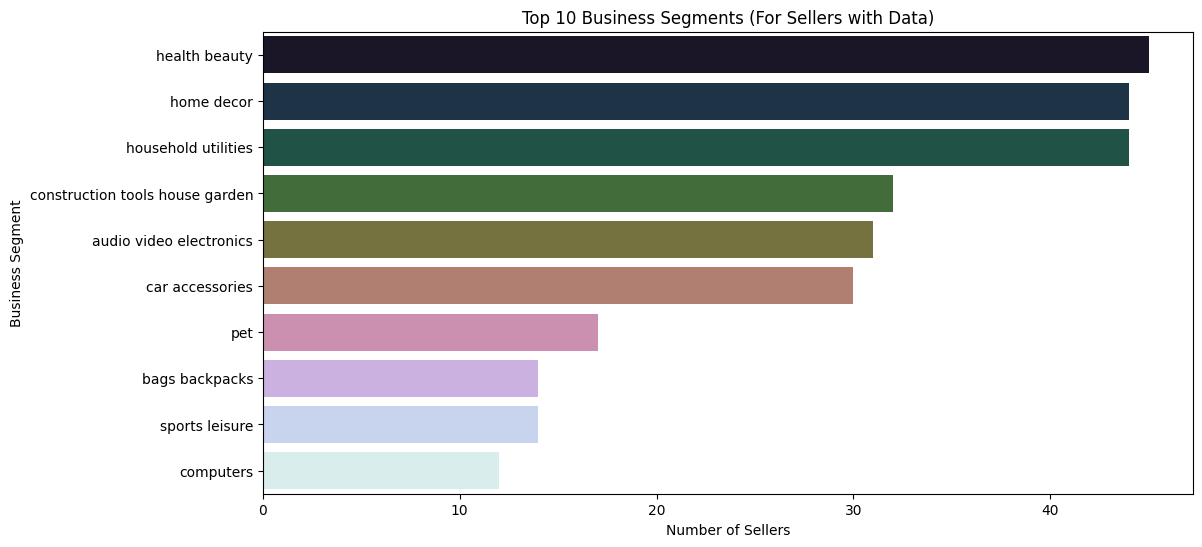

In [6]:
print("--- Missing Values Percentage ---")
missing_pct = (Dim_Sellers.isnull().sum() / len(Dim_Sellers)) * 100
print(missing_pct.round(2).astype(str) + '%')

top_seller_states = Dim_Sellers['state'].value_counts().head(10).reset_index()
top_seller_states.columns = ['state', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_seller_states, x='state', y='count', palette='crest')
plt.title('Top 10 States by Number of Sellers')
plt.xlabel('State')
plt.ylabel('Number of Sellers')
plt.show()

marketing_counts = Dim_Sellers['came_from_marketing'].value_counts()

plt.figure(figsize=(15, 12))
plt.pie(marketing_counts, labels=['Organic (False)', 'Marketing (True)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('How Sellers Were Acquired (Marketing vs Organic)')
plt.show()

business_segments = Dim_Sellers['business_segment'].dropna().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=business_segments.values, y=business_segments.index, palette='cubehelix')
plt.title('Top 10 Business Segments (For Sellers with Data)')
plt.xlabel('Number of Sellers')
plt.ylabel('Business Segment')
plt.show()

## Fact_Orders

--- Missing Values ---
order_id                    0
customer_unique_id          0
purchase_date_key           0
order_status                0
total_payment               1
primary_payment_type        1
review_score            34392
review_text             72625
delivery_days_actual     2965
is_late_delivery         2965
is_invalid_payment          0
load_date_timestamp         0
dtype: int64


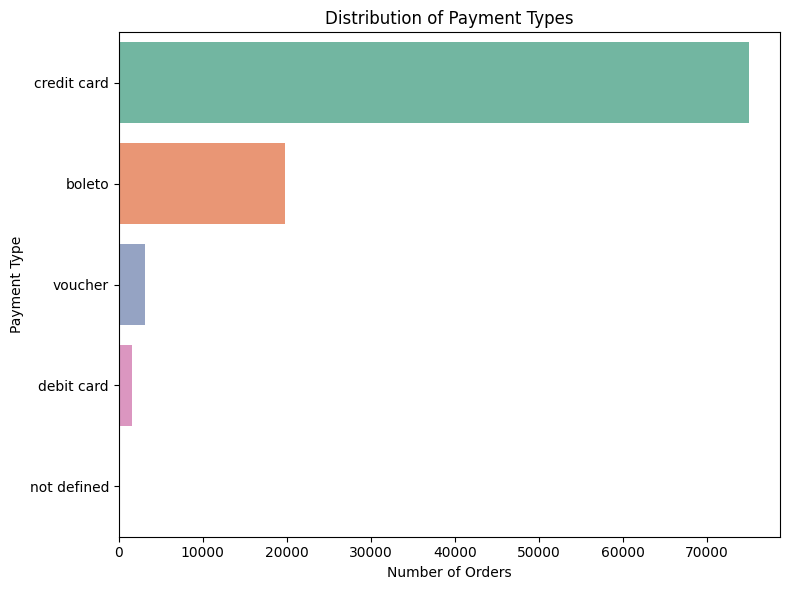

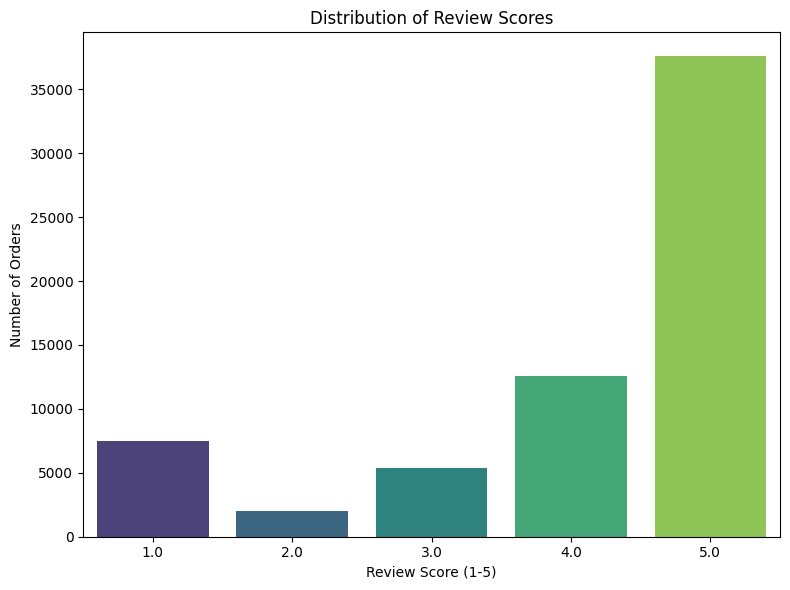

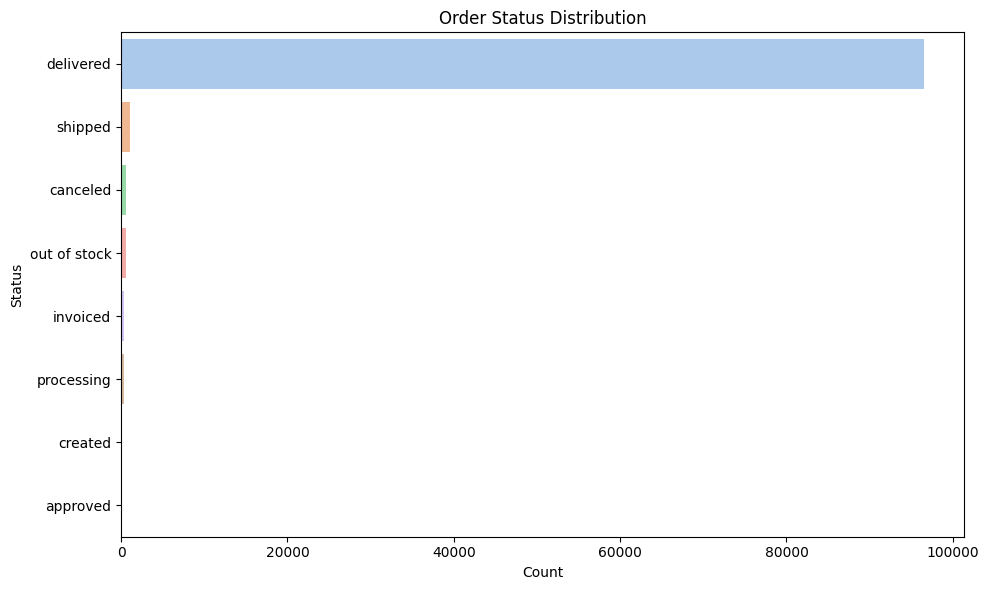

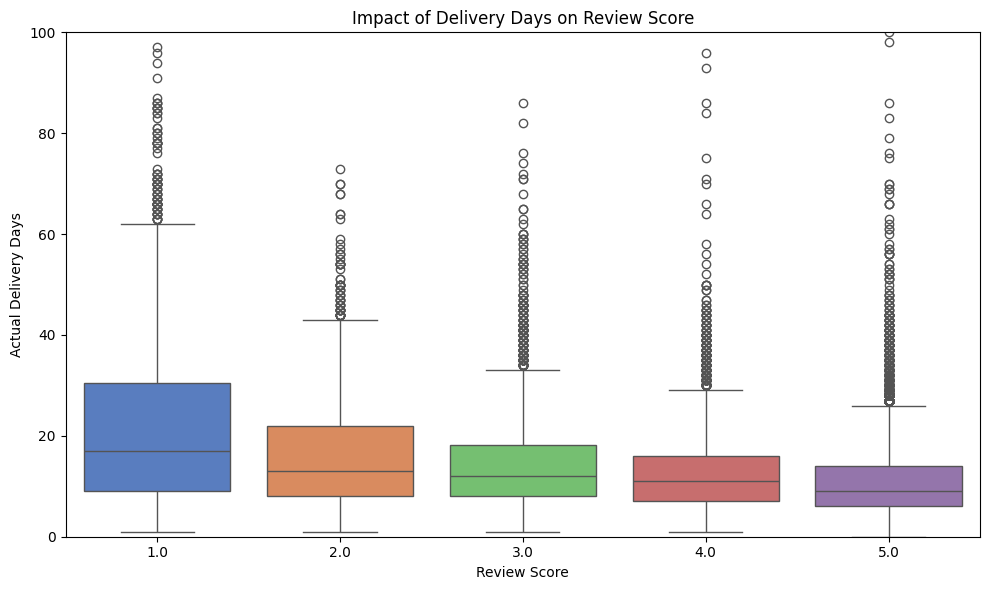

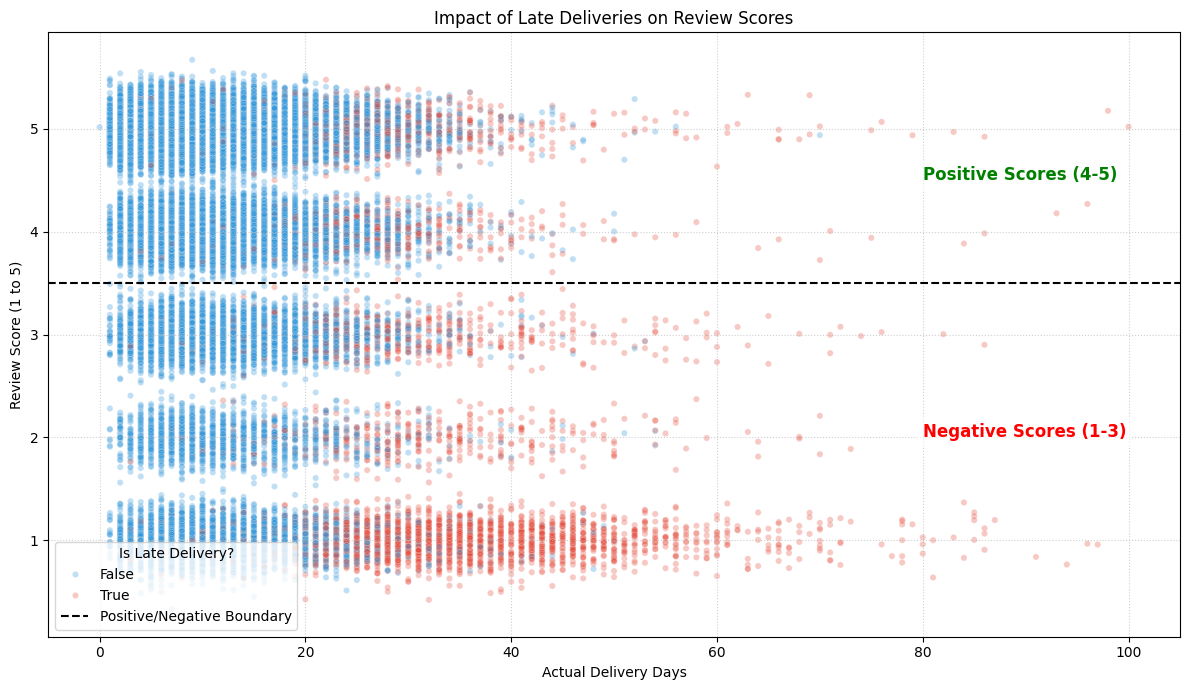

In [7]:
print("--- Missing Values ---")
print(Fact_Orders.isnull().sum())

plt.figure(figsize=(8, 6))
sns.countplot(data=Fact_Orders, y='primary_payment_type', order=Fact_Orders['primary_payment_type'].value_counts().index, palette='Set2')
plt.title('Distribution of Payment Types')
plt.xlabel('Number of Orders')
plt.ylabel('Payment Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(data=Fact_Orders, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=Fact_Orders, y='order_status', order=Fact_Orders['order_status'].value_counts().index, palette='pastel')
plt.title('Order Status Distribution')
plt.xlabel('Count')
plt.ylabel('Status')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=Fact_Orders, x='review_score', y='delivery_days_actual', palette='muted')
plt.title('Impact of Delivery Days on Review Score')
plt.xlabel('Review Score')
plt.ylabel('Actual Delivery Days')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

np.random.seed(42)
Fact_Orders['review_score_jitter'] = Fact_Orders['review_score'] + np.random.normal(0, 0.15, size=len(Fact_Orders))
df_plot = Fact_Orders[Fact_Orders['delivery_days_actual'] <= 100]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_plot,
    x='delivery_days_actual',
    y='review_score_jitter',
    hue='is_late_delivery',
    palette={True: '#e74c3c', False: '#3498db'},
    alpha=0.3,
    s=20
)
plt.axhline(3.5, color='black', linestyle='--', linewidth=1.5, label='Positive/Negative Boundary')
plt.text(x=80, y=4.5, s='Positive Scores (4-5)', fontsize=12, color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.text(x=80, y=2.0, s='Negative Scores (1-3)', fontsize=12, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
plt.title('Impact of Late Deliveries on Review Scores')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Review Score (1 to 5)')
plt.yticks([1, 2, 3, 4, 5])
plt.legend(title='Is Late Delivery?', loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Fact_Orders_Items

--- Missing Values ---
order_item_key                      0
order_id                            0
product_id                          0
seller_id                           0
purchase_date_key                   0
order_purchase_timestamp            0
order_delivered_customer_date    2454
price                               0
freight_value                       0
total_item_value                    0
load_date_timestamp                 0
dtype: int64

--- Summary Statistics ---
               price  freight_value  total_item_value
count  112650.000000  112650.000000     112650.000000
mean      120.653739      19.990320        140.644059
std       183.633928      15.806405        190.724394
min         0.850000       0.000000          6.080000
25%        39.900000      13.080000         55.220000
50%        74.990000      16.260000         92.320000
75%       134.900000      21.150000        157.937500
max      6735.000000     409.680000       6929.310000


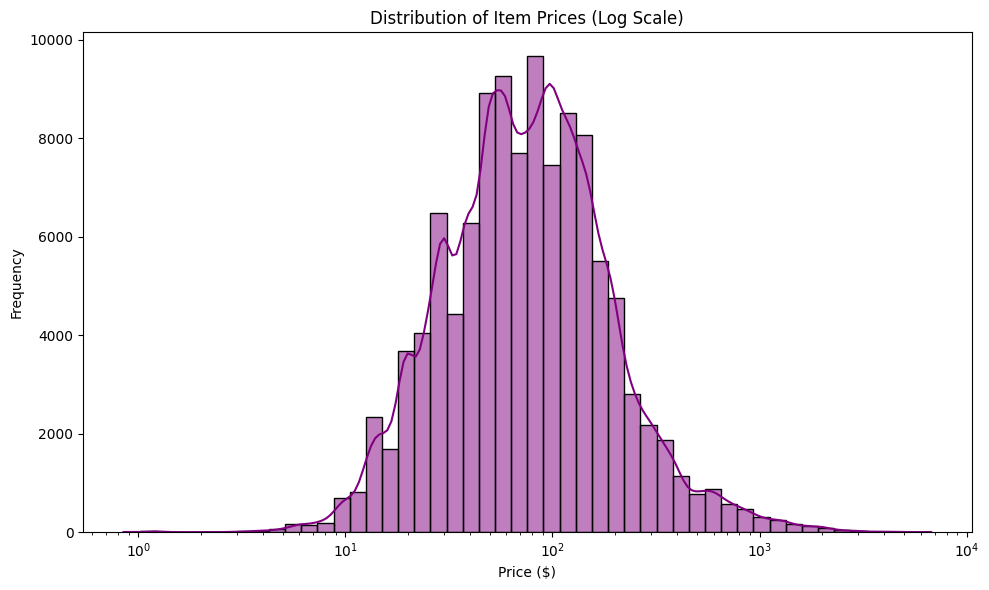

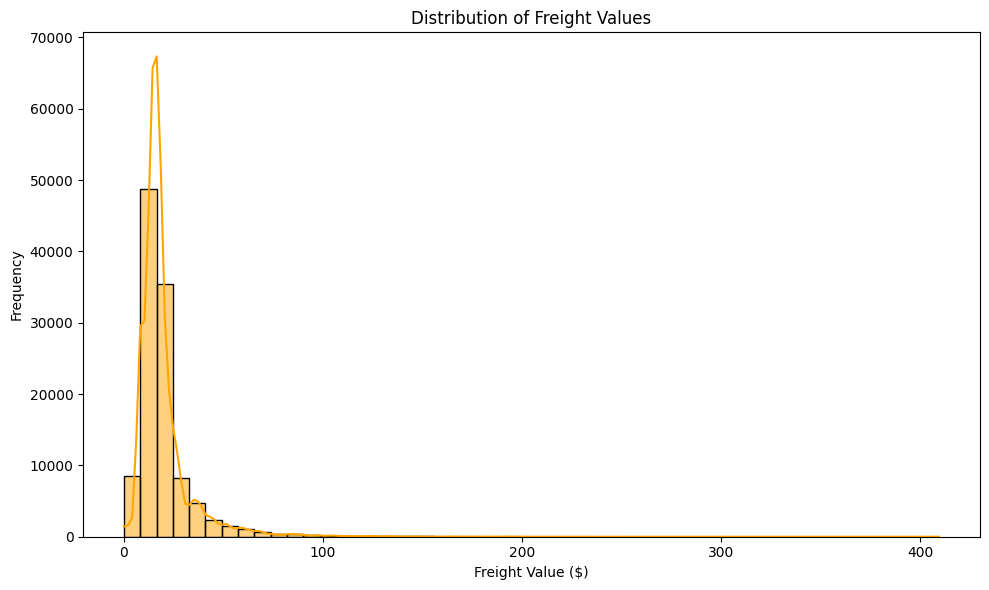

In [8]:
print("--- Missing Values ---")
print(Fact_Orders_Items.isnull().sum())

print("\n--- Summary Statistics ---")
print(Fact_Orders_Items[['price', 'freight_value', 'total_item_value']].describe())

plt.figure(figsize=(10, 6))
sns.histplot(Fact_Orders_Items['price'], bins=50, kde=True, color='purple', log_scale=True)
plt.title('Distribution of Item Prices (Log Scale)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(Fact_Orders_Items['freight_value'], bins=50, kde=True, color='orange')
plt.title('Distribution of Freight Values')
plt.xlabel('Freight Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Fact_Marketing

--- Missing Values ---
mql_id                       0
seller_id                 7620
first_contact_date_key       0
won_date_key              7158
lead_origin                 60
landing_page_id              0
sdr_id                    7158
sr_id                     7158
is_converted                 0
days_to_close             7158
load_date_timestamp          0
dtype: int64


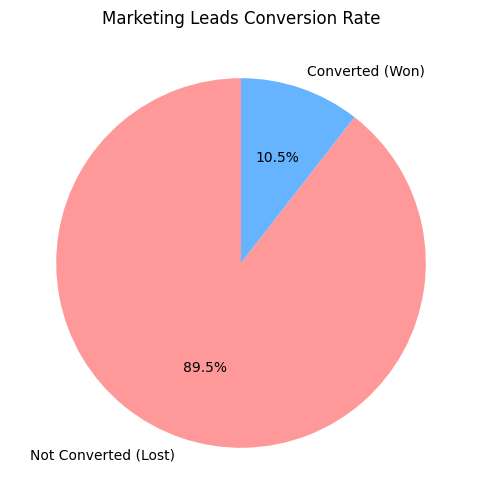

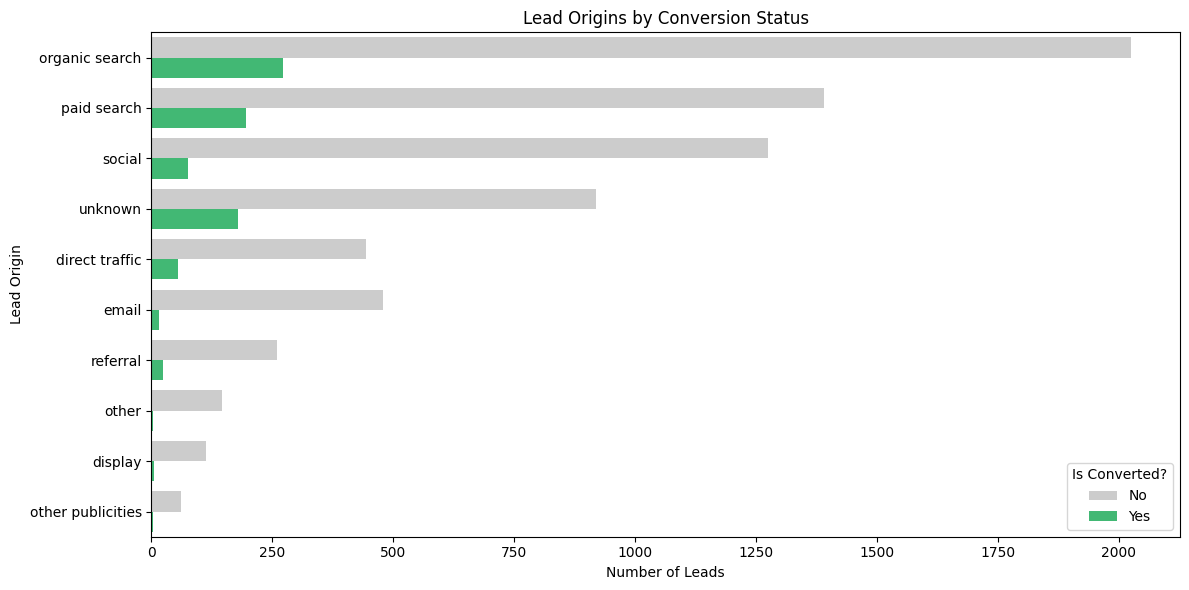

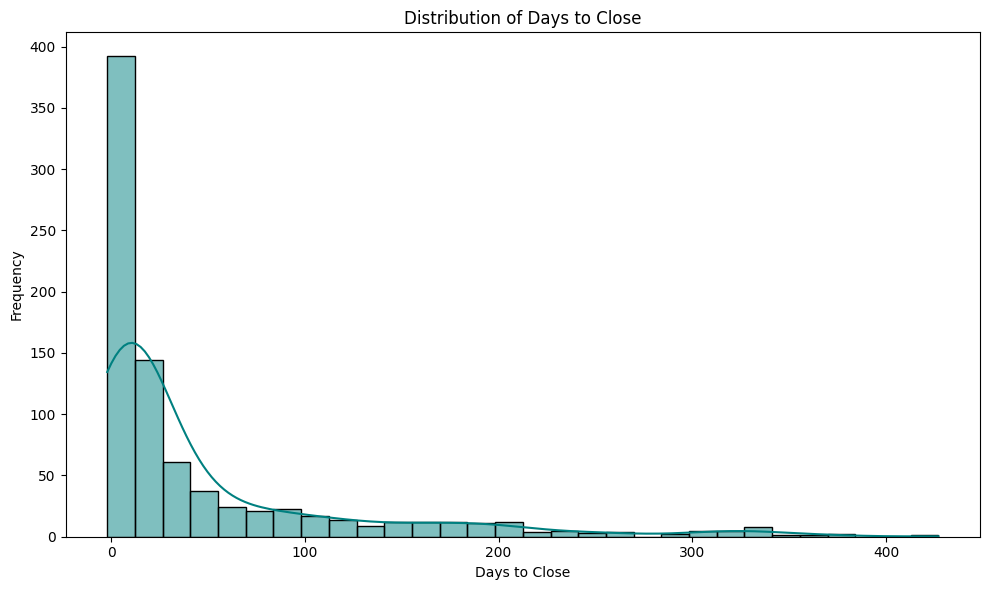

In [9]:
print("--- Missing Values ---")
print(Fact_Marketing.isnull().sum())

plt.figure(figsize=(8, 6))
conversion_counts = Fact_Marketing['is_converted'].value_counts()
plt.pie(conversion_counts, labels=['Not Converted (Lost)', 'Converted (Won)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Marketing Leads Conversion Rate')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=Fact_Marketing, y='lead_origin', hue='is_converted', order=Fact_Marketing['lead_origin'].value_counts().index, palette={False: '#cccccc', True: '#2ecc71'})
plt.title('Lead Origins by Conversion Status')
plt.xlabel('Number of Leads')
plt.ylabel('Lead Origin')
plt.legend(title='Is Converted?', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(Fact_Marketing['days_to_close'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Days to Close')
plt.xlabel('Days to Close')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Modeling

## Text Preprocessing using spaCy

In [10]:
nlp_df = pd.read_sql("SELECT * FROM Gold.Fact_Orders", engine).drop(columns=['order_id', 'customer_unique_id', 'purchase_date_key', 'load_date_timestamp'])
nlp_df = nlp_df.dropna(subset='review_text').dropna().reset_index(drop=True)

nlp = spacy.load('pt_core_news_lg')

def refine_review(text):
    doc = nlp(text)
    important_tags = ['NOUN', 'ADJ', 'VERB', 'ADV']
    clean_tokens = [
        token.lemma_.lower()
        for token in doc
        if (not token.is_stop or token.text == 'não')
        and token.pos_ in important_tags
        and len(token.text) > 2
    ]
    return ' '.join(clean_tokens)

score_map = {1: 0, 2: 0, 3: 0,
             4: 1, 5: 1}

nlp_df['review_score'] = nlp_df['review_score'].map(score_map)
nlp_df['review_text'] = nlp_df['review_text'].apply(refine_review)
nlp_df = nlp_df[nlp_df['review_text'].str.strip() != '']

print(nlp_df.info())
nlp_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 24459 entries, 0 to 25624
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_status          24459 non-null  object 
 1   total_payment         24459 non-null  float64
 2   primary_payment_type  24459 non-null  object 
 3   review_score          24459 non-null  int64  
 4   review_text           24459 non-null  object 
 5   delivery_days_actual  24459 non-null  float64
 6   is_late_delivery      24459 non-null  object 
 7   is_invalid_payment    24459 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 1.5+ MB
None


,order_status,total_payment,primary_payment_type,review_score,review_text,delivery_days_actual,is_late_delivery,is_invalid_payment
0,delivered,72.19,credit card,1,perfeito produto entregar combinado,7.0,False,False
1,delivered,216.87,credit card,1,chegar prazo prever produto surpreender qualid...,8.0,False,False
2,delivered,218.04,credit card,1,gostar vir prazo determinar,25.0,False,False
3,delivered,68.87,credit card,1,caixa produto vir pequeno avariação resto vir ...,5.0,False,False
4,delivered,97.32,credit card,1,excelente serviço compra,7.0,False,False


## Modeling Training

In [11]:
bool_encoder = FunctionTransformer(lambda X: (X.astype(str) == 'True').astype(int))

preprocessor = ColumnTransformer(transformers = [
    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), ['primary_payment_type', 'order_status']),
    ('scaler', RobustScaler(), ['delivery_days_actual', 'total_payment']),
    ('vectorizer', TfidfVectorizer(ngram_range= (1, 2), min_df = 7, max_df = .8), 'review_text'),
    ('bools', bool_encoder, ['is_late_delivery', 'is_invalid_payment'])
], remainder = 'passthrough')

In [12]:
X = nlp_df.drop(columns = 'review_score')
y = nlp_df['review_score']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = .2,
                                                    stratify = y, random_state = 30)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (19567, 7)
X_test shape: (4892, 7)


In [13]:
# CONFIG
random_state = 30
n_splits     = 5
n_trials     = 50
scoring      = "f1_macro"
thresholds = [.2, .25, .3, .35, .4, .45, .5]
results    = []

skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = random_state)

# Each model block writes its proba here
test_proba = {}

### Logistic Regression

In [14]:
def objective_lgr(trial):
    max_features = trial.suggest_int('preprocessor__vectorizer__max_features', 500, 2500, step = 500)
    lgr_params = {'classifier__C': trial.suggest_float('classifier__C', 0.01, 10.0, log=True),
                  'classifier__max_iter': trial.suggest_int('classifier__max_iter', 1000, 3000),
                  'classifier__class_weight': trial.suggest_categorical('classifier__class_weight', ['balanced', None])}
    
    ml_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state = random_state))
    ])
    
    ml_pipeline.set_params(
        preprocessor__vectorizer__max_features = max_features,
        **lgr_params
    )
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                             cv = skf, scoring = scoring, n_jobs = 1)
    
    if np.isnan(scores).any():
        return 0.0
    return scores.mean() - (scores.std() * .5)

study_lgr = optuna.create_study(direction = 'maximize')
study_lgr.optimize(objective_lgr, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_lgr.best_value:.3f}")
print(f"  Best params      : {study_lgr.best_params}")

lgr_best = ml_pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(random_state = random_state))
])
lgr_best.set_params(**study_lgr.best_params)
lgr_best.fit(X_train, y_train)

lr_proba = lgr_best.predict_proba(X_test)
lr_pred = lgr_best.predict(X_test)

test_proba["Logistic Regression"] = lr_proba[:, 0]   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, lr_pred, digits = 2))
print("-"*55)

[I 2026-05-09 20:59:31,179] A new study created in memory with name: no-name-34a63494-b5eb-40ee-a39f-57d9b2c4a0c0
Best trial: 0. Best value: 0.857298:   2%|▏         | 1/50 [00:02<02:22,  2.92s/it]

[I 2026-05-09 20:59:34,137] Trial 0 finished with value: 0.8572982806111531 and parameters: {'preprocessor__vectorizer__max_features': 1500, 'classifier__C': 0.09578594923733084, 'classifier__max_iter': 2480, 'classifier__class_weight': 'balanced'}. Best is trial 0 with value: 0.8572982806111531.


Best trial: 0. Best value: 0.857298:   4%|▍         | 2/50 [00:05<01:57,  2.44s/it]

[I 2026-05-09 20:59:36,245] Trial 1 finished with value: 0.7907130912563001 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 0.045749588364958266, 'classifier__max_iter': 1525, 'classifier__class_weight': None}. Best is trial 0 with value: 0.8572982806111531.


Best trial: 2. Best value: 0.86803:   6%|▌         | 3/50 [00:07<02:03,  2.63s/it] 

...

[I 2026-05-09 21:01:40,443] Trial 47 finished with value: 0.8710338770212231 and parameters: {'preprocessor__vectorizer__max_features': 2500, 'classifier__C': 1.4446736536084337, 'classifier__max_iter': 2684, 'classifier__class_weight': 'balanced'}. Best is trial 22 with value: 0.8718140384041791.


Best trial: 22. Best value: 0.871814:  98%|█████████▊| 49/50 [02:12<00:02,  2.82s/it]

[I 2026-05-09 21:01:43,698] Trial 48 finished with value: 0.8687448421635755 and parameters: {'preprocessor__vectorizer__max_features': 2000, 'classifier__C': 3.78243796939521, 'classifier__max_iter': 2916, 'classifier__class_weight': 'balanced'}. Best is trial 22 with value: 0.8718140384041791.


Best trial: 22. Best value: 0.871814: 100%|██████████| 50/50 [02:15<00:00,  2.72s/it]


[I 2026-05-09 21:01:47,096] Trial 49 finished with value: 0.8654482453082963 and parameters: {'preprocessor__vectorizer__max_features': 2500, 'classifier__C': 6.541155967373035, 'classifier__max_iter': 2351, 'classifier__class_weight': 'balanced'}. Best is trial 22 with value: 0.8718140384041791.

✔ Best CV f1_macro : 0.872
  Best params      : {'preprocessor__vectorizer__max_features': 2500, 'classifier__C': 1.0267643896013061, 'classifier__max_iter': 2414, 'classifier__class_weight': 'balanced'}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1655
           1       0.94      0.89      0.91      3237

    accuracy                           0.89      4892
   macro avg       0.87      0.89      0.88      4892
weighted avg       0.89      0.89      0.89      4892

-------------------------------------------------------


### Naive Bayes

In [15]:
# Returning a Dense dataframe
def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else X


def objective_nb(trial):
    max_features = trial.suggest_int('preprocessor__vectorizer__max_features', 500, 2500, step = 500)
    nb_params = {
        'classifier__var_smoothing': trial.suggest_float('classifier__var_smoothing', 1e-12, 1e-6, log = True)
    }
    
    ml_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('to_dense', FunctionTransformer(to_dense, accept_sparse = True)),
        ('classifier', GaussianNB())
    ])
    
    ml_pipeline.set_params(
        preprocessor__vectorizer__max_features = max_features,
        **nb_params
    )
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                             cv = skf, scoring = scoring, n_jobs = 1)
    
    if np.isnan(scores).any():
        return 0.0
    return scores.mean() - (scores.std() * .5)

study_nb = optuna.create_study(direction = 'maximize')
study_nb.optimize(objective_nb, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_nb.best_value:.3f}")
print(f"  Best params      : {study_nb.best_params}")

nb_best = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('to_dense', FunctionTransformer(to_dense, accept_sparse = True)),
        ('classifier', GaussianNB())
])
nb_best.set_params(**study_nb.best_params)
nb_best.fit(X_train, y_train)

nb_proba = nb_best.predict_proba(X_test)
nb_pred = nb_best.predict(X_test)

test_proba["Naive Bayes"] = nb_proba[:, 0]   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, nb_pred, digits = 2))
print("-"*55)

[I 2026-05-09 21:01:47,954] A new study created in memory with name: no-name-8b8b8c7b-da03-468a-9b6b-409a873556d3
Best trial: 0. Best value: 0.842282:   2%|▏         | 1/50 [00:04<03:27,  4.23s/it]

[I 2026-05-09 21:01:52,208] Trial 0 finished with value: 0.842281761115557 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 6.421072704395418e-07}. Best is trial 0 with value: 0.842281761115557.


Best trial: 0. Best value: 0.842282:   4%|▍         | 2/50 [00:08<03:18,  4.13s/it]

[I 2026-05-09 21:01:56,264] Trial 1 finished with value: 0.8322847473411035 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 3.542608226272688e-12}. Best is trial 0 with value: 0.842281761115557.


Best trial: 0. Best value: 0.842282:   6%|▌         | 3/50 [00:13<03:45,  4.79s/it]

...

[I 2026-05-09 21:05:20,209] Trial 47 finished with value: 0.8419455427996858 and parameters: {'preprocessor__vectorizer__max_features': 1500, 'classifier__var_smoothing': 4.0030816177907085e-08}. Best is trial 24 with value: 0.8429628276563299.


Best trial: 24. Best value: 0.842963:  98%|█████████▊| 49/50 [03:35<00:03,  3.92s/it]

[I 2026-05-09 21:05:23,870] Trial 48 finished with value: 0.8421775053817143 and parameters: {'preprocessor__vectorizer__max_features': 1000, 'classifier__var_smoothing': 9.372384804828576e-07}. Best is trial 24 with value: 0.8429628276563299.


Best trial: 24. Best value: 0.842963: 100%|██████████| 50/50 [03:40<00:00,  4.41s/it]


[I 2026-05-09 21:05:28,608] Trial 49 finished with value: 0.8385581672691247 and parameters: {'preprocessor__vectorizer__max_features': 1500, 'classifier__var_smoothing': 6.211547552996023e-10}. Best is trial 24 with value: 0.8429628276563299.

✔ Best CV f1_macro : 0.843
  Best params      : {'preprocessor__vectorizer__max_features': 1500, 'classifier__var_smoothing': 2.0336930203267378e-07}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1655
           1       0.92      0.86      0.89      3237

    accuracy                           0.86      4892
   macro avg       0.84      0.86      0.85      4892
weighted avg       0.87      0.86      0.86      4892

-------------------------------------------------------


### Model Comparison

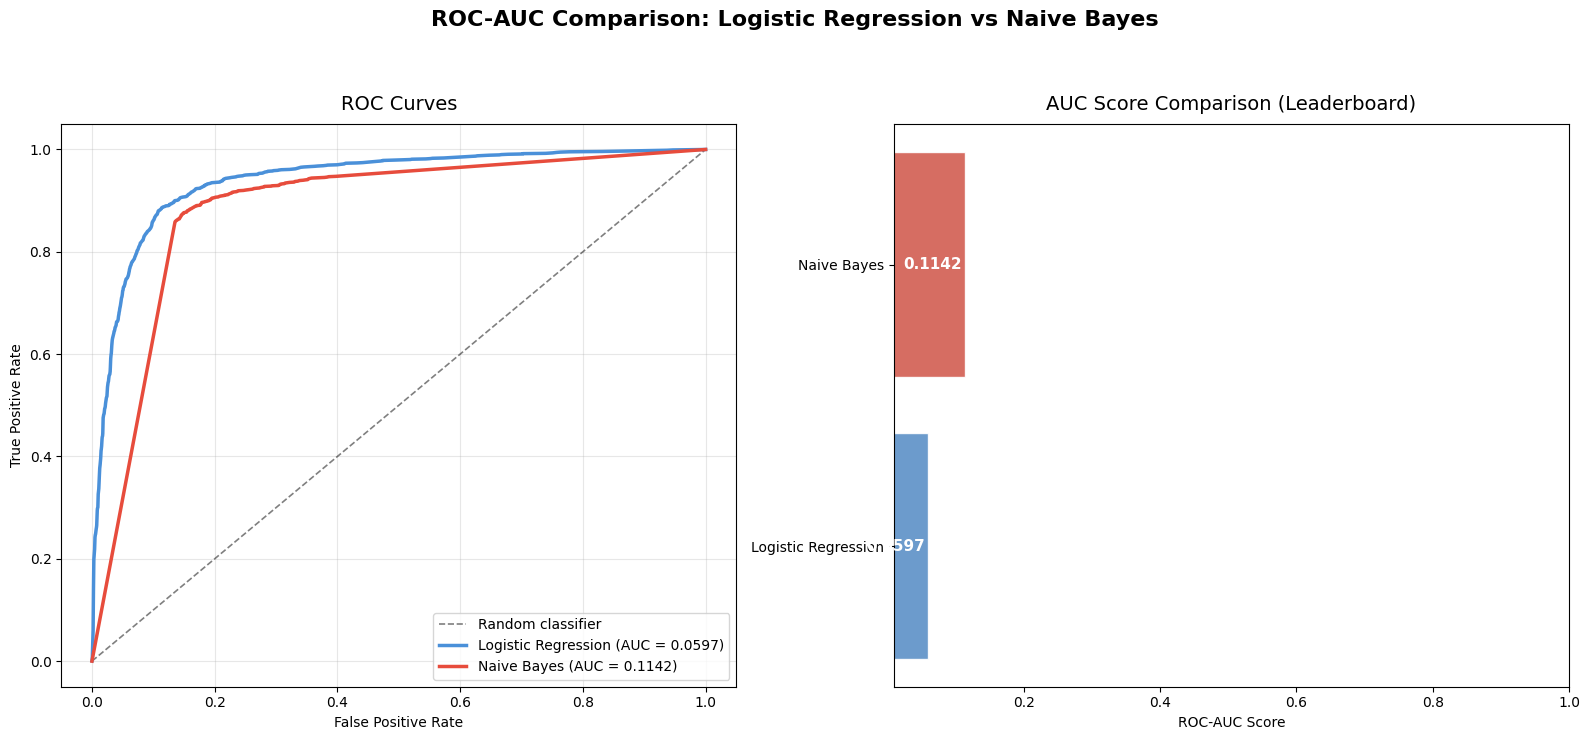


═════════════════════════════════════════════
RANK  MODEL                     TEST AUC  
─────────────────────────────────────────────
1     Naive Bayes               0.1142     ⭐
2     Logistic Regression       0.0597       
═════════════════════════════════════════════


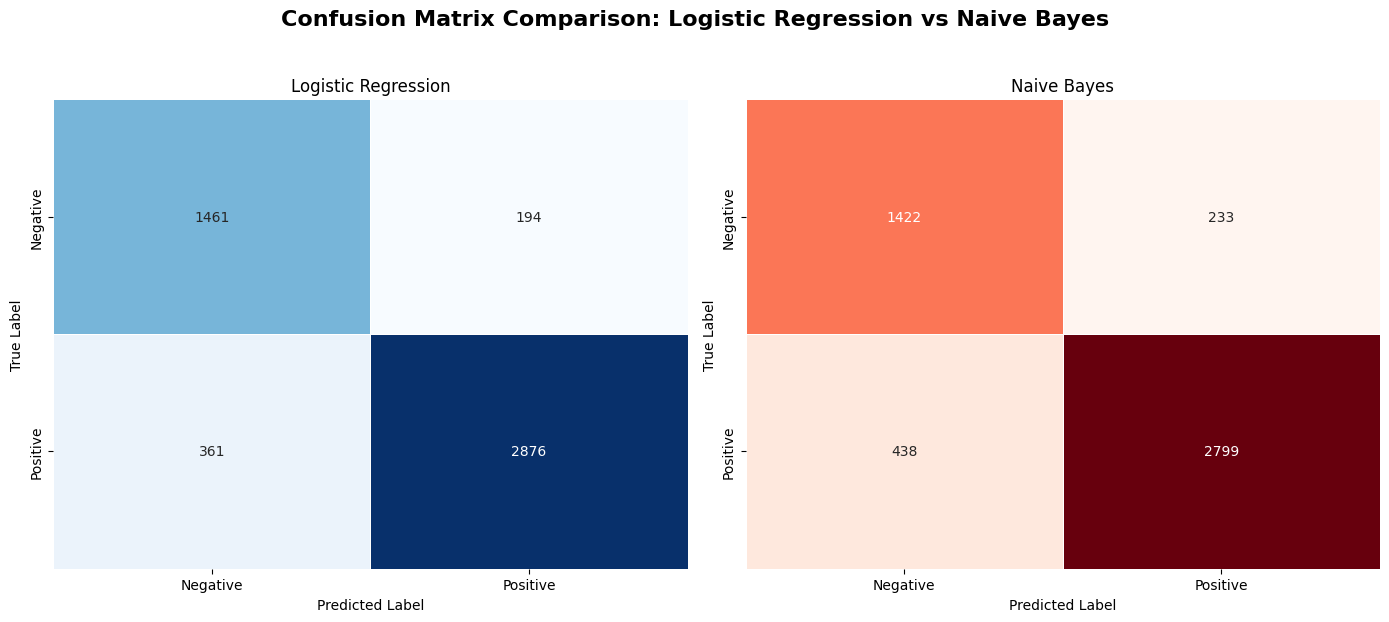

In [ ]:
COLORS = {
    "Logistic Regression": "#4A90D9",
    "Naive Bayes": "#E74C3C",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC-AUC Comparison: Logistic Regression vs Naive Bayes", 
             fontsize=16, fontweight="bold", y=1.05)

ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier", alpha=0.5)

rows = []
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = auc(fpr, tpr)
    rows.append({"Model": name, "AUC": score})
    
    sns.lineplot(x=tpr, y=fpr, ax=ax, lw=2.5, color=COLORS.get(name, "#333333"),
                 label=f"{name} (AUC = {score:.4f})")

ax.set_title("ROC Curves", fontsize=14, pad=10)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=True)

ax2 = axes[1]
df_aucs = pd.DataFrame(rows).sort_values("AUC", ascending=False)

sns.barplot(data=df_aucs, x='AUC', y='Model', palette=COLORS, 
            ax=ax2, hue='Model', legend=False, alpha=0.9, edgecolor="white")

for i, val in enumerate(df_aucs['AUC']):
    ax2.text(val - 0.005, i, f"{val:.4f}", va='center', ha='right', 
             color='white', fontweight='bold', fontsize=11)

ax2.set_title("AUC Score Comparison (Leaderboard)", fontsize=14, pad=10)

min_auc = df_aucs['AUC'].min()
ax2.set_xlim([max(0, min_auc - 0.05), 1.0])
ax2.set_xlabel("ROC-AUC Score")
ax2.set_ylabel("") 

plt.tight_layout()
plt.show()

print("\n" + "═"*45)
print(f"{'RANK':<5} {'MODEL':<25} {'TEST AUC':<10}")
print("─" * 45)
for i, row in enumerate(df_aucs.itertuples(), 1):
    star = "⭐" if i == 1 else "  "
    print(f"{i:<5} {row.Model:<25} {row.AUC:<10.4f} {star}")
print("═"*45)

# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrix Comparison: Logistic Regression vs Naive Bayes", 
             fontsize=16, fontweight="bold", y=1.03)

lr_cm = confusion_matrix(y_test, lr_pred)
nb_cm = confusion_matrix(y_test, nb_pred)
labels = ["Negative", "Positive"]

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[1], linewidths=0.5, linecolor='white')
axes[1].set_title("Naive Bayes")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Feature Importance

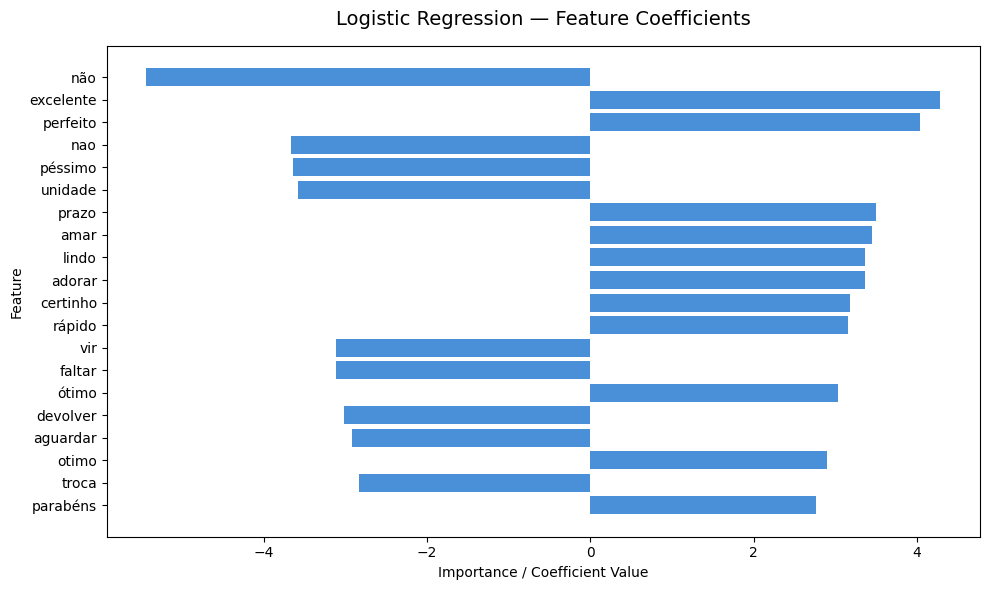

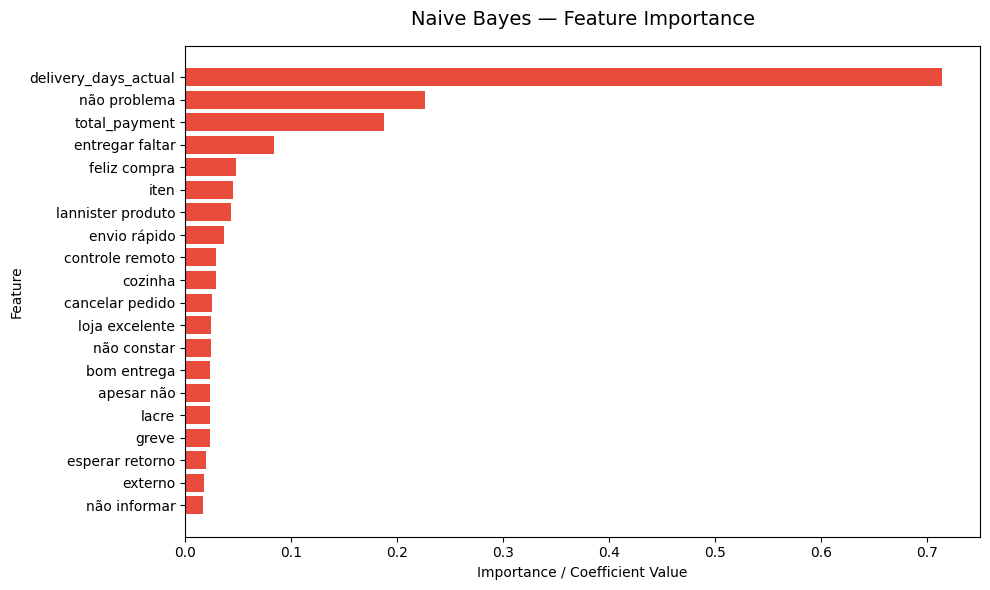

In [17]:
def plot_feature_importance(importances, feature_names, title, color, top_n=20):
    feature_names = np.asarray(feature_names)
    importances = np.asarray(importances)

    limit = min(len(feature_names), len(importances))
    feature_names = feature_names[:limit]
    importances = importances[:limit]

    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
    df_imp = df_imp.reindex(df_imp["importance"].abs().sort_values(ascending=False).index)
    df_imp = df_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color=color)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance / Coefficient Value")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()


def get_preprocessor_feature_names(fitted_preprocessor):
    feature_names = []

    for name, transformer, columns in fitted_preprocessor.transformers_:
        if name == 'remainder' and transformer == 'passthrough':
            feature_names.extend(list(columns))
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                feature_names.extend(transformer.get_feature_names_out(columns))
            except TypeError:
                feature_names.extend(transformer.get_feature_names_out())
        else:
            if isinstance(columns, (list, tuple, np.ndarray)):
                feature_names.extend(list(columns))
            else:
                feature_names.append(columns)

    return np.asarray(feature_names, dtype=object)


feature_names = get_preprocessor_feature_names(lgr_best.named_steps['preprocessor'])

plot_feature_importance(
    importances   = lgr_best.named_steps['classifier'].coef_[0],
    feature_names = feature_names,
    title         = "Logistic Regression — Feature Coefficients",
    color         = "#4A90D9"
)

nb_model = nb_best.named_steps['classifier']
nb_feature_importance = np.abs(nb_model.theta_[1] - nb_model.theta_[0])

plot_feature_importance(
    importances   = nb_feature_importance,
    feature_names = feature_names,
    title         = "Naive Bayes — Feature Importance",
    color         = "#E74C3C"
)